# 00 - Data Exploration
**Kompetisi:** INFEST XII 2026 - Data Science (Klasifikasi Aksara Tradisional Nusantara)
**Tim:** Fadhil - Percobaan 1

Notebook ini berisi eksplorasi awal terhadap dataset sebelum masuk ke tahap preprocessing dan modeling.
Tujuan: memahami karakteristik data (distribusi kelas, ukuran gambar, kualitas gambar) sehingga keputusan
preprocessing dan pemilihan model pada notebook berikutnya punya dasar yang jelas.

**Isi notebook:**
1. Setup & Load Data
2. Overview Struktur Dataset
3. Distribusi Kelas (Label)
4. Visualisasi Sample Gambar per Kelas
5. Analisis Ukuran & Properti Gambar
6. Cek Anomali / Kualitas Data
7. Kesimpulan & Insight Awal


## 1. Setup & Load Data

In [40]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Path (relatif terhadap folder notebook/)
DATA_DIR = "../dataset"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_CSV = os.path.join(DATA_DIR, "sample_submission.csv")
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "images", "train")
TEST_IMG_DIR = os.path.join(DATA_DIR, "images", "test")

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_sub_df = pd.read_csv(SAMPLE_SUB_CSV)

print("Train shape :", train_df.shape)
print("Test shape  :", test_df.shape)
print("Sample sub  :", sample_sub_df.shape)


Train shape : (4468, 2)
Test shape  : (1118, 1)
Sample sub  : (1118, 2)


In [41]:
train_df.head()

,image_id,label
0,SxrIaKaJ.png,pegon
1,XiR75p4l.png,jawi
2,gpadO4eH.png,jawa
3,IlL62jcp.png,lampung
4,7bEtcJPy.png,bali


In [42]:
test_df.head()

,image_id
0,AQmumubg.png
1,nbXfeFmw.png
2,mUdL9acm.png
3,FgSrN0Ad.png
4,n7xv3e7m.png


In [43]:
sample_sub_df.head()

,image_id,label
0,AQmumubg.png,sunda
1,nbXfeFmw.png,lampung
2,mUdL9acm.png,jawa
3,FgSrN0Ad.png,jawa
4,n7xv3e7m.png,bali


## 2. Overview Struktur Dataset

Cek info umum: tipe data, missing value, jumlah file gambar vs jumlah baris di CSV
(untuk memastikan tidak ada gambar yang hilang / tidak terpakai).

In [44]:
train_df.info()
print()
print("Missing values per kolom:")
print(train_df.isnull().sum())
print()
print("Jumlah label unik:", train_df['label'].nunique())
print("Daftar kelas:", sorted(train_df['label'].unique()))


<class 'pandas.DataFrame'>
RangeIndex: 4468 entries, 0 to 4467
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image_id  4468 non-null   str  
 1   label     4468 non-null   str  
dtypes: str(2)
memory usage: 144.7 KB

Missing values per kolom:
image_id    0
label       0
dtype: int64

Jumlah label unik: 7
Daftar kelas: ['bali', 'jawa', 'jawi', 'lampung', 'lontara', 'pegon', 'sunda']


In [45]:
# Cek kecocokan jumlah file gambar dengan jumlah baris CSV
train_files = set(os.listdir(TRAIN_IMG_DIR))
test_files = set(os.listdir(TEST_IMG_DIR))

print("Jumlah file di folder train:", len(train_files))
print("Jumlah baris train.csv    :", len(train_df))
print("Selisih (file - csv)      :", len(train_files) - len(train_df))
print()
print("Jumlah file di folder test:", len(test_files))
print("Jumlah baris test.csv     :", len(test_df))
print("Selisih (file - csv)      :", len(test_files) - len(test_df))

# Cek apakah semua image_id di train.csv benar-benar ada filenya
missing_train_imgs = set(train_df['image_id']) - train_files
missing_test_imgs = set(test_df['image_id']) - test_files
print()
print("image_id di train.csv tapi file tidak ditemukan:", len(missing_train_imgs))
print("image_id di test.csv tapi file tidak ditemukan :", len(missing_test_imgs))


Jumlah file di folder train: 4468
Jumlah baris train.csv    : 4468
Selisih (file - csv)      : 0

Jumlah file di folder test: 1118
Jumlah baris test.csv     : 1118
Selisih (file - csv)      : 0

image_id di train.csv tapi file tidak ditemukan: 0
image_id di test.csv tapi file tidak ditemukan : 0


## 3. Distribusi Kelas (Label)

Karena metrik evaluasi lomba adalah **F1-Score Macro**, setiap kelas dihitung setara tanpa memandang
jumlah sampelnya. Artinya class imbalance yang parah bisa sangat merugikan skor jika model condong
ke kelas mayoritas. Bagian ini penting untuk menentukan strategi di notebook preprocessing
(oversampling, class weighting, augmentasi terarah, dll).

label
lampung    823
jawi       814
pegon      771
sunda      658
jawa       653
lontara    382
bali       367
Name: count, dtype: int64


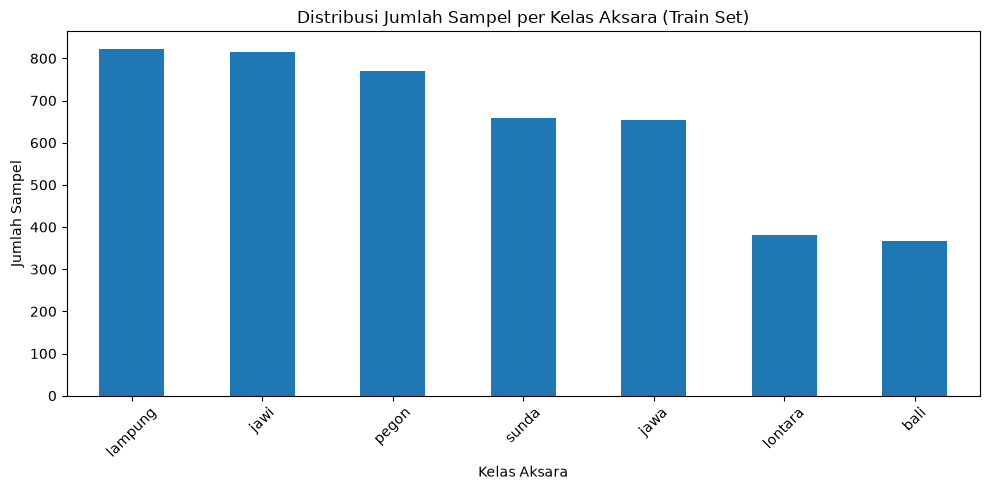

In [46]:
class_counts = train_df['label'].value_counts().sort_values(ascending=False)
print(class_counts)

plt.figure(figsize=(10, 5))
class_counts.plot(kind='bar')
plt.title("Distribusi Jumlah Sampel per Kelas Aksara (Train Set)")
plt.xlabel("Kelas Aksara")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [47]:
# Rasio imbalance: kelas terbanyak vs kelas tersedikit
max_class = class_counts.idxmax()
min_class = class_counts.idxmin()
ratio = class_counts.max() / class_counts.min()

print(f"Kelas terbanyak : {max_class} ({class_counts.max()} sampel)")
print(f"Kelas tersedikit: {min_class} ({class_counts.min()} sampel)")
print(f"Rasio imbalance : {ratio:.2f}x")


Kelas terbanyak : lampung (823 sampel)
Kelas tersedikit: bali (367 sampel)
Rasio imbalance : 2.24x


> **Catatan interpretasi :**
> - Dataset imbalance moderat, rasio 2.24x antara kelas terbanyak (lampung, 823 sampel) dan kelas tersedikit (bali, 367 sampel). Tidak ekstrem, tapi cukup signifikan untuk mempengaruhi F1-Score Macro jika tidak ditangani, karena metrik ini menghitung tiap kelas setara tanpa memandang jumlah sampelnya.
> - Kelas yang berisiko sulit dikenali: bali (367) dan lontara (380), karena jumlah sampelnya paling sedikit — sekitar separuh dari kelas terbanyak. Model berpotensi bias ke kelas mayoritas (lampung, jawi, pegon) kalau tidak ada penanganan khusus.

## 4. Visualisasi Sample Gambar per Kelas

Melihat langsung contoh gambar tiap kelas untuk memahami karakteristik visual masing-masing aksara
(bentuk goresan, ada tidaknya noise/background, variasi tulisan tangan vs cetak).

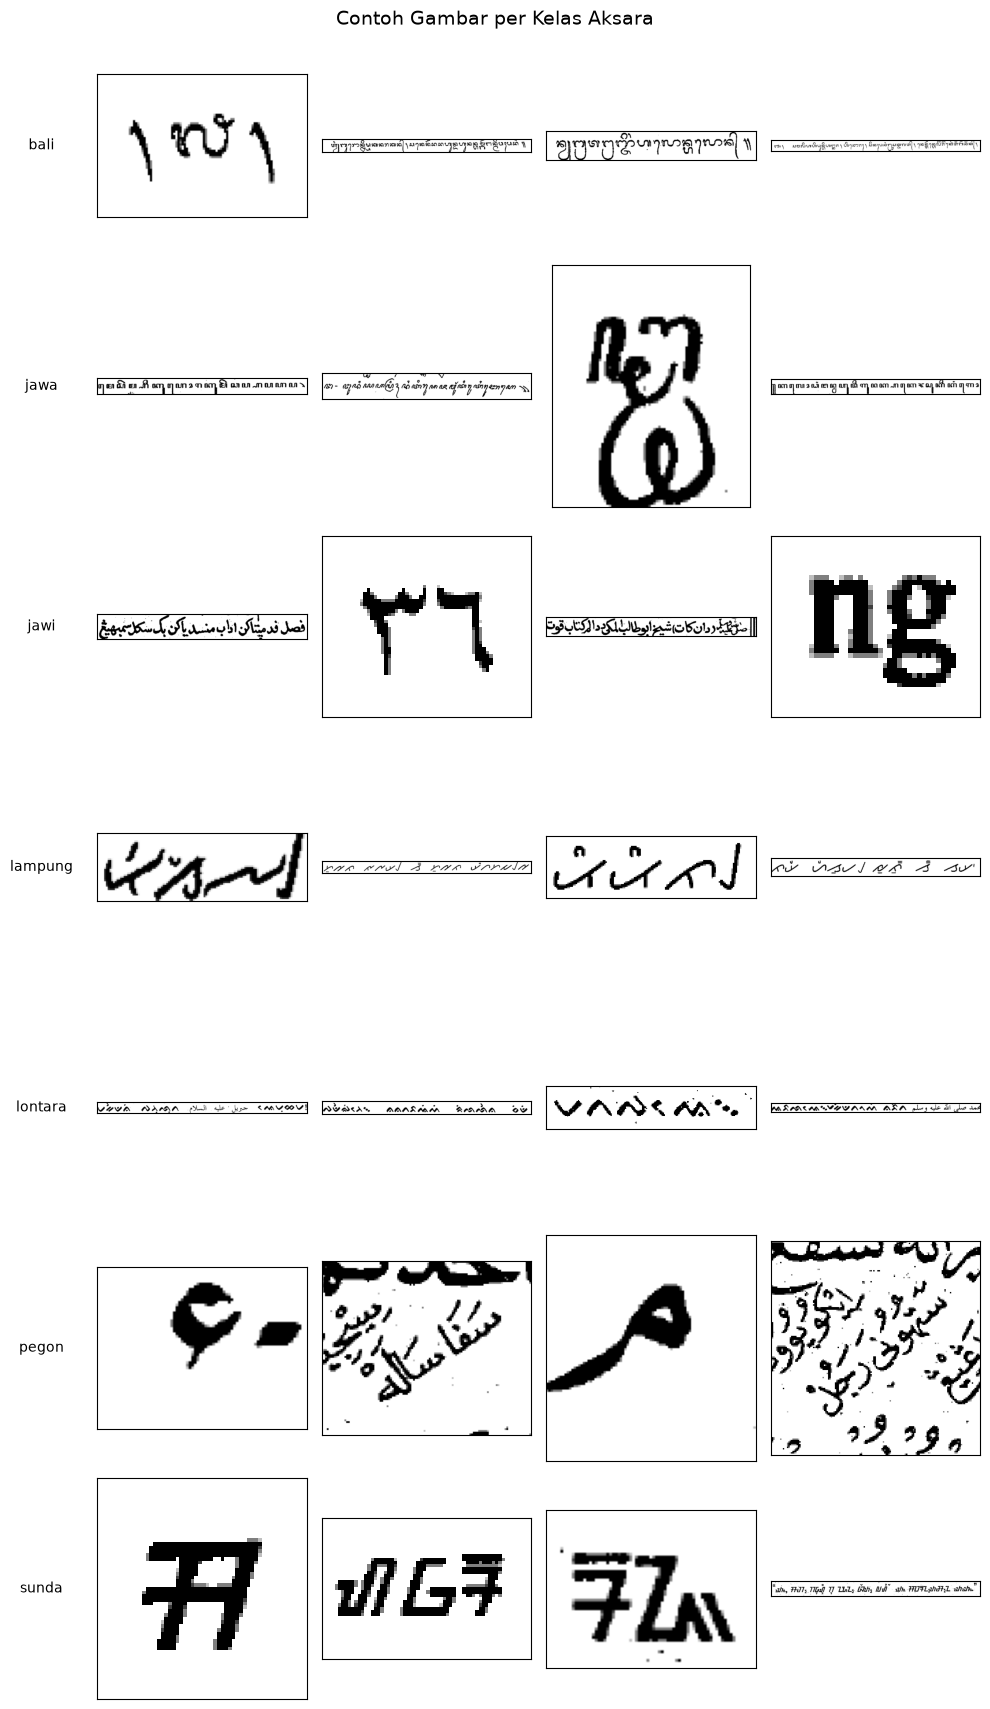

In [48]:
def show_samples_per_class(df, img_dir, n_per_class=3):
    classes = sorted(df['label'].unique())
    n_classes = len(classes)

    fig, axes = plt.subplots(n_classes, n_per_class, figsize=(n_per_class * 2.5, n_classes * 2.5))
    if n_classes == 1:
        axes = axes.reshape(1, -1)

    for i, cls in enumerate(classes):
        subset = df[df['label'] == cls]['image_id'].sample(
            min(n_per_class, len(subset := df[df['label'] == cls])), random_state=SEED
        ).tolist()
        for j in range(n_per_class):
            ax = axes[i, j]
            if j < len(subset):
                img_path = os.path.join(img_dir, subset[j])
                img = Image.open(img_path)
                ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
                if j == 0:
                    ax.set_ylabel(cls, fontsize=10, rotation=0, labelpad=40, va='center')
            ax.set_xticks([])
            ax.set_yticks([])

    plt.suptitle("Contoh Gambar per Kelas Aksara", fontsize=14)
    plt.tight_layout()
    plt.show()

show_samples_per_class(train_df, TRAIN_IMG_DIR, n_per_class=4)


> **Catatan interpretasi :**
> - Ada tulisan jawi bertuliskan ng latin

## 5. Analisis Ukuran & Properti Gambar

Cek resolusi, rasio aspek, dan mode warna gambar. Informasi ini menentukan strategi resize dan
normalisasi pada tahap preprocessing.

In [49]:
def get_image_properties(df, img_dir, sample_size=None):
    image_ids = df['image_id'].tolist()
    if sample_size:
        image_ids = random.sample(image_ids, min(sample_size, len(image_ids)))

    records = []
    for img_id in image_ids:
        img_path = os.path.join(img_dir, img_id)
        with Image.open(img_path) as img:
            w, h = img.size
            records.append({
                "image_id": img_id,
                "width": w,
                "height": h,
                "aspect_ratio": round(w / h, 3),
                "mode": img.mode
            })
    return pd.DataFrame(records)

# Gunakan sample dulu (misal 500) supaya cepat; bisa diganti None untuk cek semua data
props_df = get_image_properties(train_df, TRAIN_IMG_DIR, sample_size=500)
props_df.describe()


,width,height,aspect_ratio
count,500.000000,500.000000,500.000000
mean,455.488000,69.062000,7.255192
std,399.240152,30.228359,6.685298
min,14.000000,19.000000,0.667000
25%,127.000000,46.000000,1.697750
50%,246.000000,63.000000,4.085500
75%,806.250000,79.000000,11.565000
max,1556.000000,180.000000,29.100000


Distribusi mode warna gambar:
mode
RGB    500
Name: count, dtype: int64



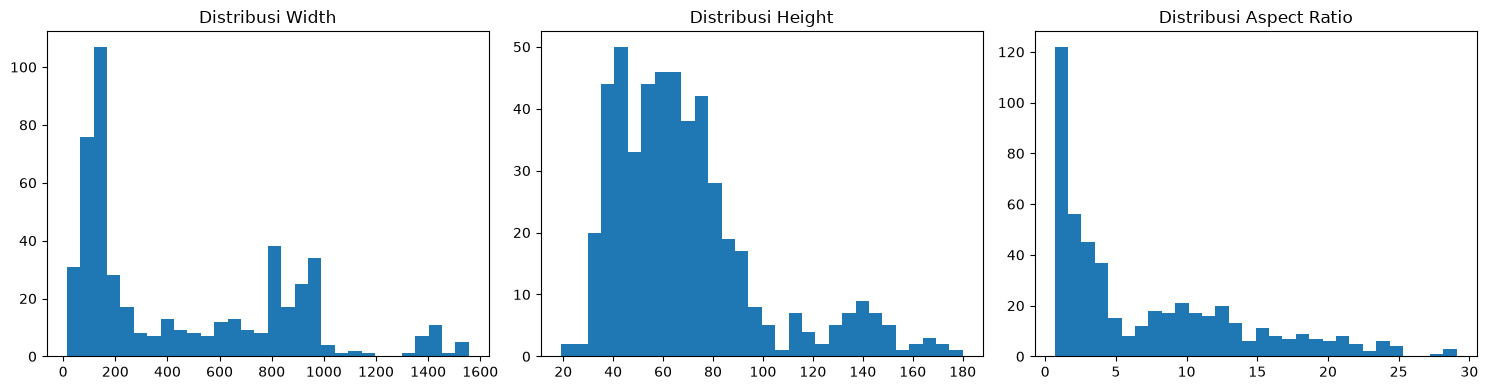

In [50]:
print("Distribusi mode warna gambar:")
print(props_df['mode'].value_counts())
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(props_df['width'], bins=30)
axes[0].set_title("Distribusi Width")

axes[1].hist(props_df['height'], bins=30)
axes[1].set_title("Distribusi Height")

axes[2].hist(props_df['aspect_ratio'], bins=30)
axes[2].set_title("Distribusi Aspect Ratio")

plt.tight_layout()
plt.show()


> **Catatan interpretasi :**
> - Width & Height sangat bervariasi, tidak seragam. Width didominasi di rentang 100-200px, tapi ada cluster kedua di 800-1000px dan bahkan outlier sampai 1400-1600px. Height mayoritas 40-100px dengan long tail sampai 180px.
> - Aspect ratio didominasi gambar sangat memanjang (rasio 1-5x, puncak di sekitar 1-2), konsisten dengan temuan visual sebelumnya — banyak sampel berupa strip teks (potongan baris tulisan panjang), bukan citra satu karakter berbentuk persegi. Ada juga long tail sampai aspect ratio 25-30 (gambar sangat panjang dan pipih).

## 6. Cek Anomali / Kualitas Data

Cek file corrupt, gambar duplikat, atau gambar dengan properti aneh (misal ukuran 0, mode tidak umum).

In [51]:
def check_corrupt_images(df, img_dir):
    corrupt = []
    for img_id in df['image_id']:
        img_path = os.path.join(img_dir, img_id)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            corrupt.append((img_id, str(e)))
    return corrupt

corrupt_train = check_corrupt_images(train_df, TRAIN_IMG_DIR)
print(f"Jumlah file corrupt di train: {len(corrupt_train)}")
if corrupt_train:
    print(corrupt_train[:10])


Jumlah file corrupt di train: 1
[('mPmaODVU.png', "cannot identify image file '../dataset\\\\images\\\\train\\\\mPmaODVU.png'")]


In [52]:
import hashlib

def find_duplicate_images(df, img_dir, sample_size=None):
    image_ids = df['image_id'].tolist()
    if sample_size:
        image_ids = random.sample(image_ids, min(sample_size, len(image_ids)))

    hashes = {}
    duplicates = []
    for img_id in image_ids:
        img_path = os.path.join(img_dir, img_id)
        with open(img_path, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        if h in hashes:
            duplicates.append((img_id, hashes[h]))
        else:
            hashes[h] = img_id
    return duplicates

# Sample dulu supaya cepat, bisa diganti None untuk cek seluruh data sebelum submit
dupes = find_duplicate_images(train_df, TRAIN_IMG_DIR, sample_size=500)
print(f"Jumlah duplikat terdeteksi (dari sample): {len(dupes)}")


Jumlah duplikat terdeteksi (dari sample): 0


## 6.5 Deteksi Potensi Mislabel

Saat eksplorasi visual di Section 4, ditemukan kejanggalan: salah satu sampel berlabel `jawi`
menampilkan teks Latin cetak ("ng"), bukan karakter aksara Jawi (berbasis Arab) yang seharusnya.
Section ini melakukan pengecekan lebih terarah untuk mengidentifikasi kemungkinan mislabel serupa
di kelas lain sebelum masuk ke tahap preprocessing.

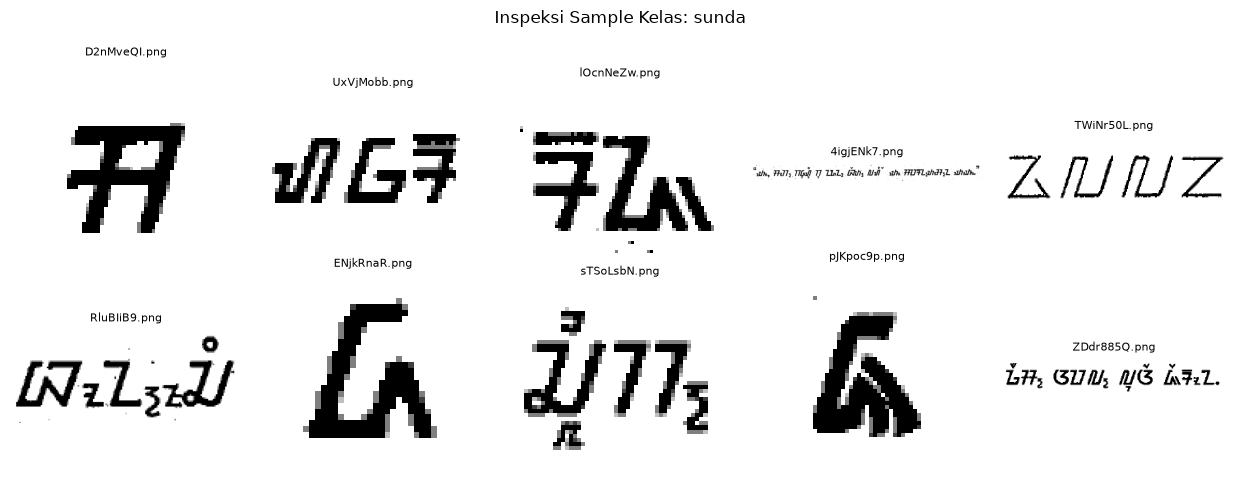

In [54]:
# Tampilkan lebih banyak sample per kelas dengan filename untuk scan manual potensi mislabel
def inspect_class_samples(df, img_dir, label, n=10):
    samples = df[df['label'] == label]['image_id'].sample(
        min(n, len(df[df['label'] == label])), random_state=SEED
    ).tolist()

    n_cols = 5
    n_rows = (len(samples) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))
    axes = axes.flatten()

    for ax, img_id in zip(axes, samples):
        img = Image.open(os.path.join(img_dir, img_id))
        ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
        ax.set_title(img_id, fontsize=8)
        ax.axis('off')

    for ax in axes[len(samples):]:
        ax.axis('off')

    plt.suptitle(f"Inspeksi Sample Kelas: {label}", fontsize=12)
    plt.tight_layout()
    plt.show()

# Cek tiap kelas satu per satu, ganti label sesuai kebutuhan
inspect_class_samples(train_df, TRAIN_IMG_DIR, label='sunda', n=10)

## 7. Kesimpulan & Insight Awal

Ringkasan temuan dari eksplorasi di atas dan implikasinya terhadap tahap selanjutnya.

**Template kesimpulan (isi manual berdasarkan hasil run):**

- **Distribusi kelas:** ... (seimbang / imbalance, kelas mana yang minoritas)
- **Karakteristik visual:** ... (kemiripan antar kelas, noise, variasi gaya tulisan)
- **Ukuran & properti gambar:** ... (resolusi umum, mode warna, perlu resize ke berapa)
- **Kualitas data:** ... (ada/tidak file corrupt & duplikat)

**Implikasi untuk tahap Preprocessing & Feature Engineering (`01_preprocessing_feature_engineering.ipynb`):**
1. ...
2. ...
3. ...

**Implikasi untuk tahap Modeling (`02_modeling.ipynb`):**
1. ...
2. ...